In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

from backtest_functions import simulate_kelly
from backtest_plots import plot_bankroll_distributions, plot_backtest 

from backtest_plots import event_analysis, plot_event_odds_stats, correlate_with_vegas, summary_stats, pmf_plot


In [ ]:
# https://vegapit.com/article/numerically_solve_kelly_criterion_multiple_simultaneous_bets/
# https://nickyoder.com/kelly-criterion/
# https://www.mma-ai.net/ 

# https://business.columbia.edu/sites/default/files-efs/pubfiles/6343/bayes_kelly.pdf
## Portfolio Choice and the Bayesian Kelly Criterion


c:\Users\jcmar\my_files\SportsBetting\BettingStrategy\KellyStrategy\betting_backtest\backtest_functions.py:468: RuntimeWarning: Mean of empty slice.
  vegas_acc_choice = np.where(np.array(group_stats['choice_decimal_odds'])[choice_idxs] < 2, 1, 0).mean()
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


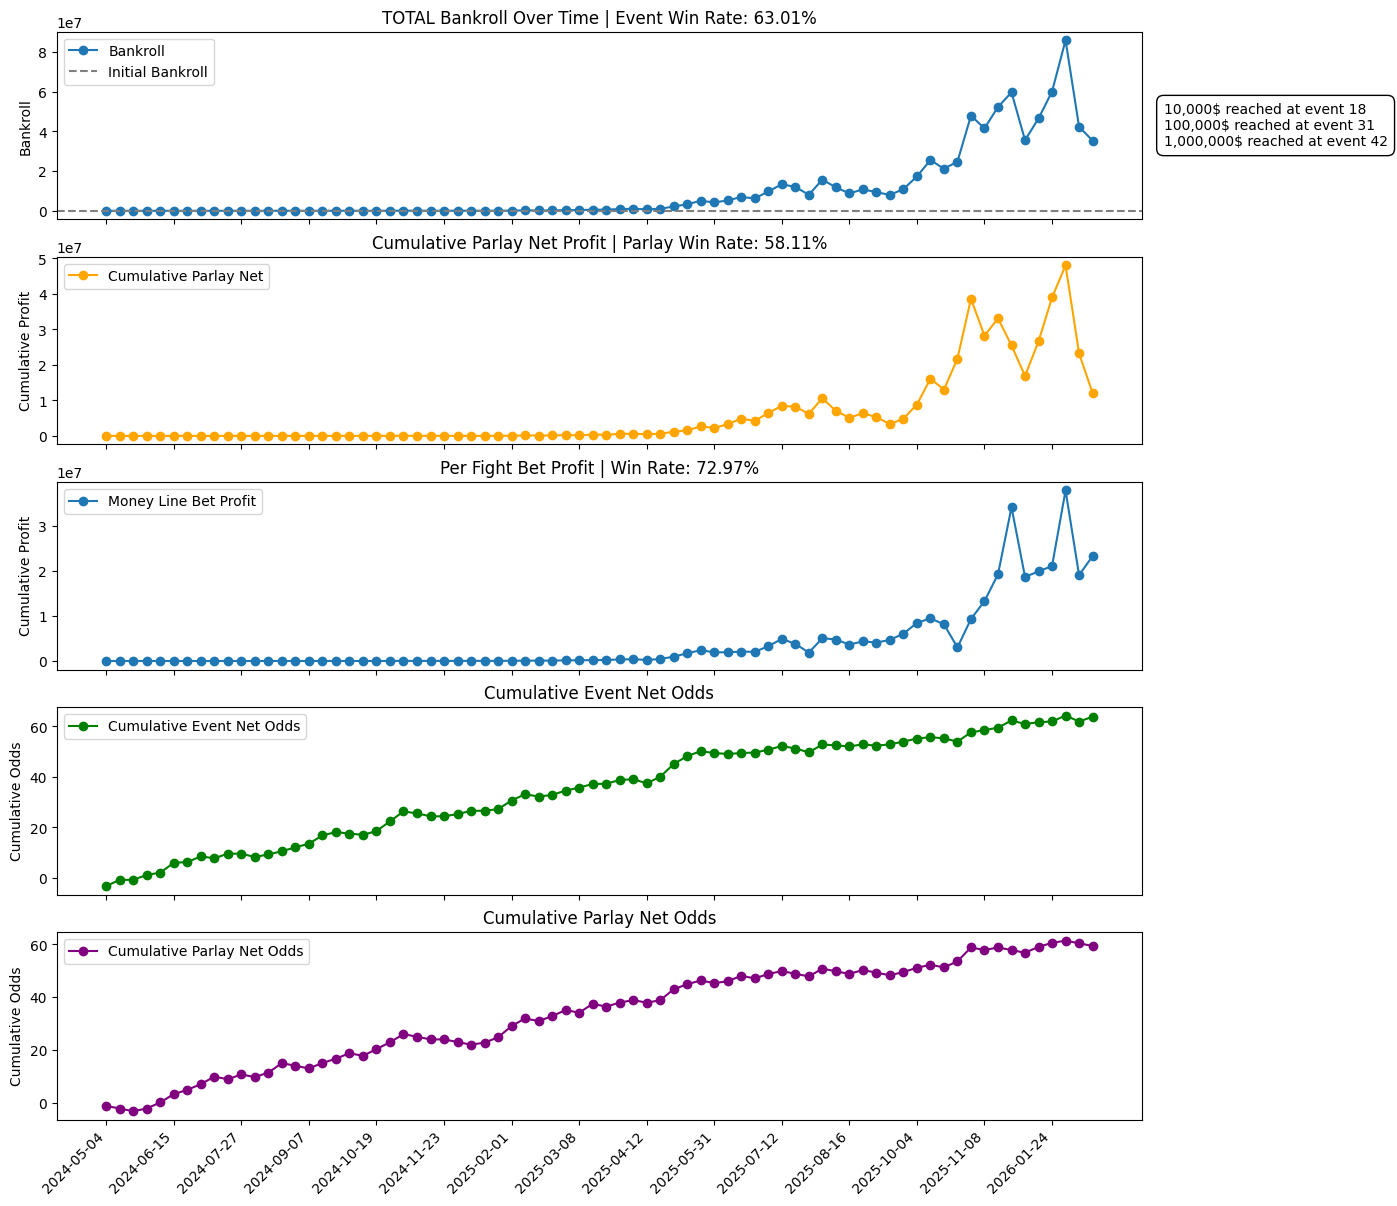

In [17]:
df_test_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_open.csv')

prob_cols = ['proba_blue', 'proba_red']
fair_decimal_odds = ['dec_fair_open_blue', 'dec_fair_open_red']  # your decimal odds columns
real_decimal_odds = ['dec_open_blue', 'dec_open_red']

df_kelly, df_parlay = simulate_kelly(
    df_test_open,
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col='pred_winner',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    portfolio_scaling=False,
    adaptive_scaling=True,  
    max_drawdown=.3,
    parlay_mdd=None,
    N=250,
    calc_parlay=True
)

# plot_bankroll_distributions(df_kelly, df_parlay)
plot_fp = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\open_kelly_sim.png'
plot_backtest(df_kelly, 500, path=plot_fp)
# plot_event_odds_stats(df_kelly)

# x_vars = ['mu_portfolio', 'sharpe_portfolio', 'portfolio_sigma']
# y_var = 'event_net_odds'
# kelly_analysis(df_kelly, x_vars, y_var)

df_kelly.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_open.csv')
df_parlay.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\streamlit\data\parlay_open.csv')

C:\Users\jcmar\AppData\Local\Temp\ipykernel_28848\3637763272.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_per_bin = df_parlay.groupby('ev_bin')['parlay_net_odds'].apply(lambda x: (x != -1).sum() / len(x)).reset_index()


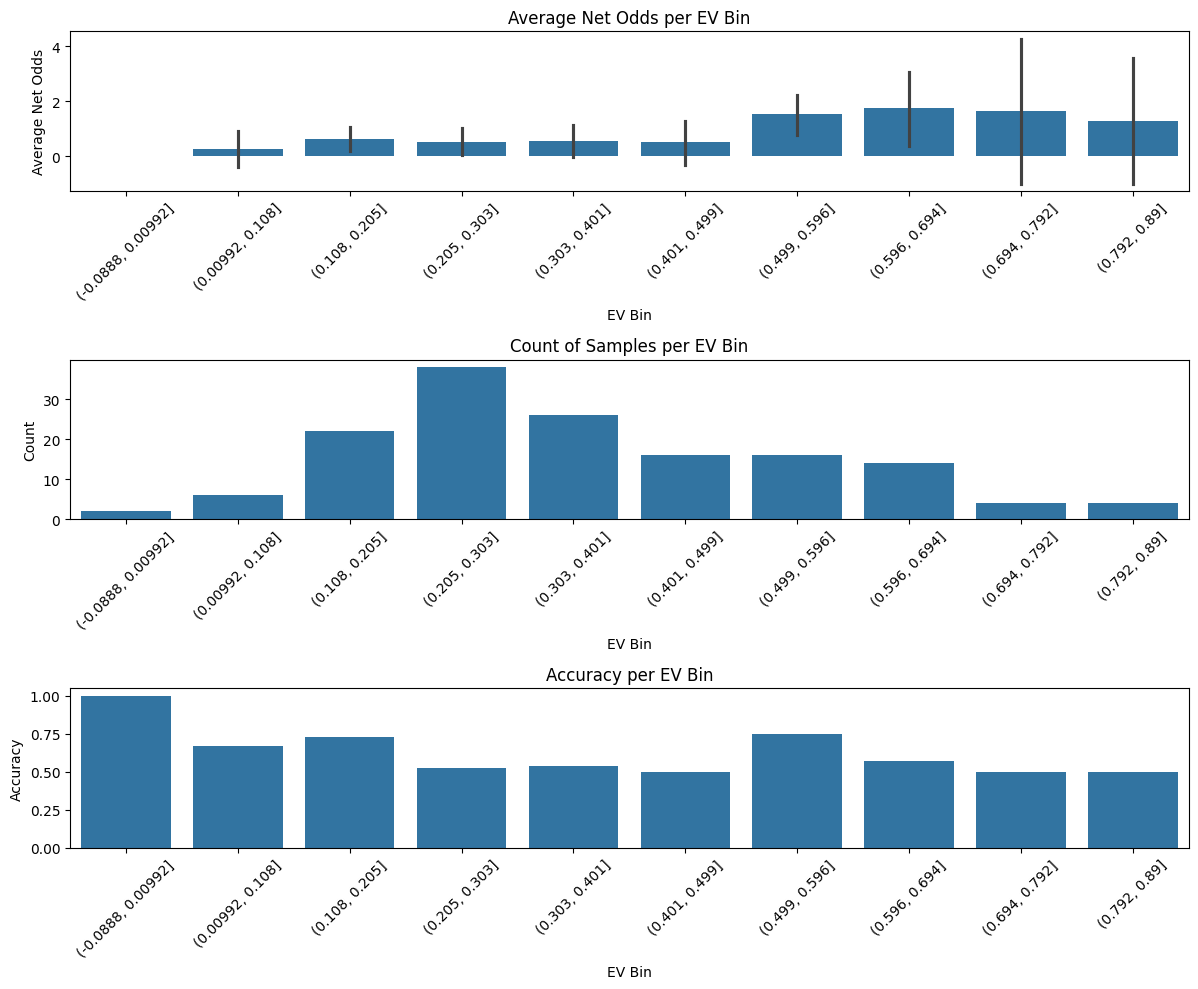

In [20]:
df_parlay['ev_bin'] = pd.cut(df_parlay['parlay_ev'], bins=10)

# Create subplot
fig, axes = plt.subplots(3, 1, figsize=(12,10))

# ---- 1. Barplot of average parlay_net_odds per bin with CI ----
sns.barplot(
    data=df_parlay,
    x='ev_bin',
    y='parlay_net_odds',
    estimator='mean',
    errorbar=('ci', 95),
    ax=axes[0]
)
axes[0].set_title("Average Net Odds per EV Bin")
axes[0].set_xlabel("EV Bin")
axes[0].set_ylabel("Average Net Odds")
axes[0].tick_params(axis='x', rotation=45)

# ---- 2. Barplot of counts per EV bin ----
sns.countplot(
    data=df_parlay,
    x='ev_bin',
    ax=axes[1]
)
axes[1].set_title("Count of Samples per EV Bin")
axes[1].set_xlabel("EV Bin")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

# Define accuracy: proportion of rows where parlay_net_odds != -1
accuracy_per_bin = df_parlay.groupby('ev_bin')['parlay_net_odds'].apply(lambda x: (x != -1).sum() / len(x)).reset_index()
accuracy_per_bin.rename(columns={'parlay_net_odds': 'accuracy'}, inplace=True)

sns.barplot(
    data=accuracy_per_bin,
    x='ev_bin',
    y='accuracy',
    ax=axes[2]
)
axes[2].set_title("Accuracy per EV Bin")
axes[2].set_xlabel("EV Bin")
axes[2].set_ylabel("Accuracy")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



In [4]:
df_parlay.columns

Index(['choice_fighter_name', 'parlay_fstar_sum', 'parlay_net_odds',
       'choice_fstar', 'choice_ev', 'choice_real_odds', 'date', 'winner',
       'pred_winner', 'choice_proba', 'parlay_prob', 'parlay_ev',
       'parlay_avg_edge', 'fstar_net', 'choice_decimal_odds'],
      dtype='object')

c:\Users\jcmar\my_files\SportsBetting\BettingStrategy\KellyStrategy\betting_backtest\backtest_functions.py:468: RuntimeWarning: Mean of empty slice.
  vegas_acc_choice = np.where(np.array(group_stats['choice_decimal_odds'])[choice_idxs] < 2, 1, 0).mean()
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jcmar\my_files\SportsBetting\BettingStrategy\KellyStrategy\betting_backtest\backtest_functions.py:468: RuntimeWarning: Mean of empty slice.
  vegas_acc_choice = np.where(np.array(group_stats['choice_decimal_odds'])[choice_idxs] < 2, 1, 0).mean()
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value en

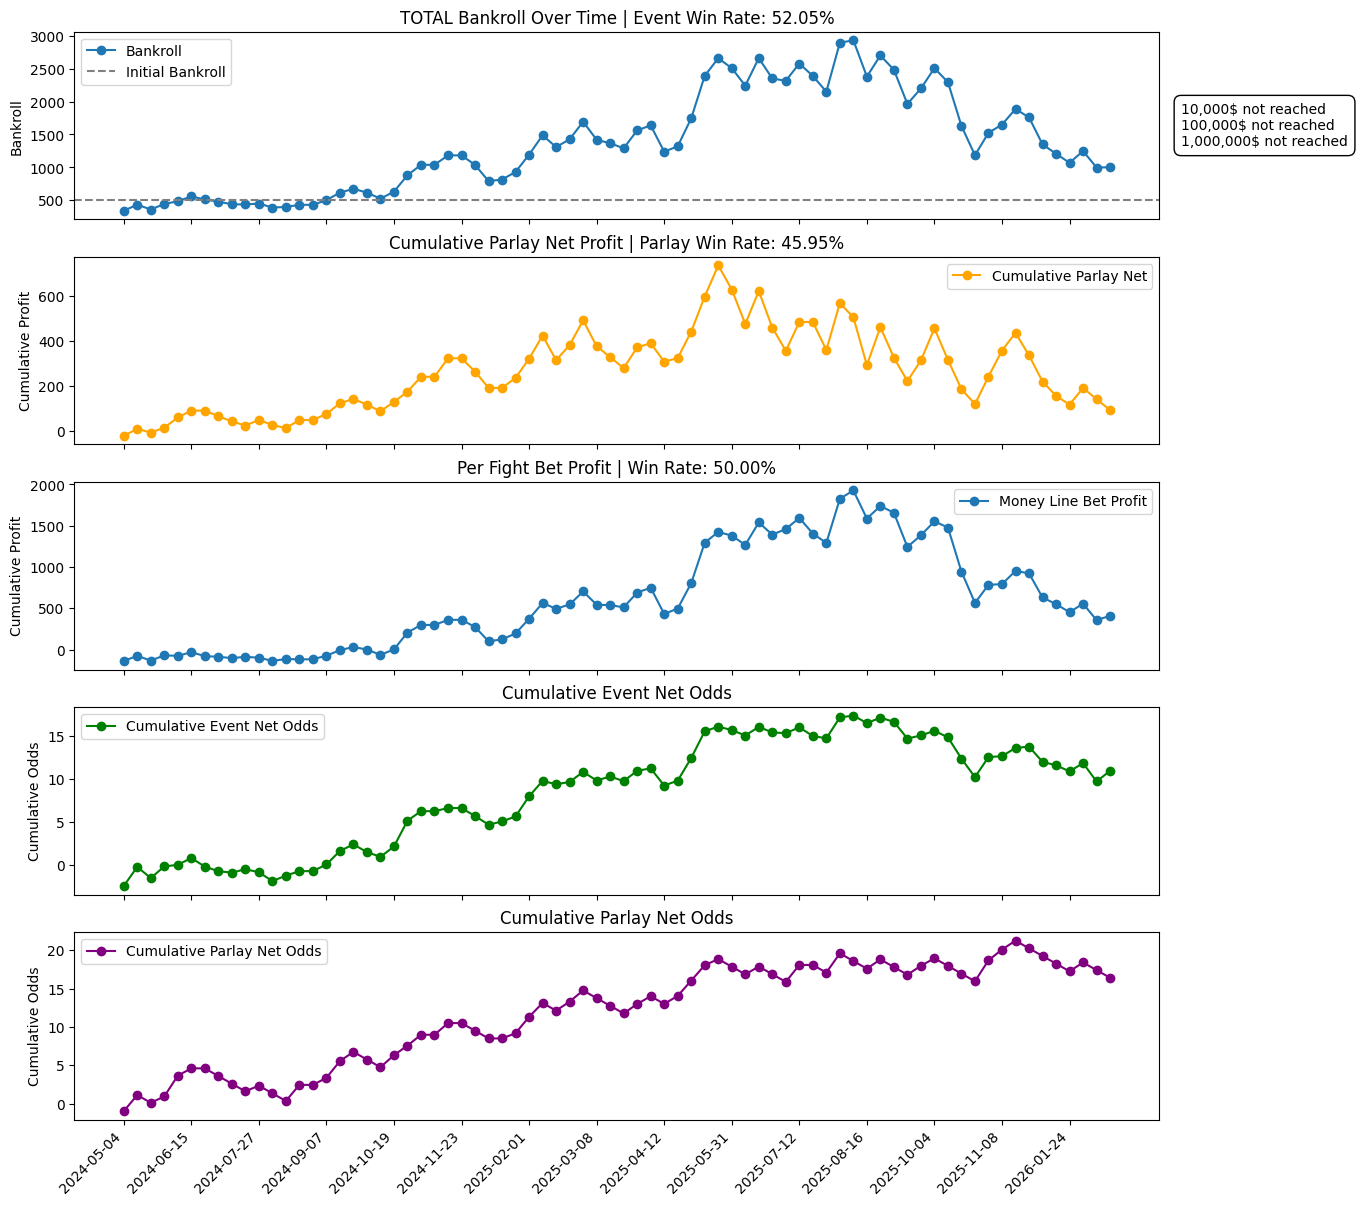

In [21]:
df_test_close = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close1.csv')

prob_cols = ['proba_blue', 'proba_red']
fair_decimal_odds = ['dec_fair_close1_blue', 'dec_fair_close1_red']  # your decimal odds columns
real_decimal_odds = ['dec_close1_blue', 'dec_close1_red']

df_kelly1, df_kelly1_parlay = simulate_kelly(
    df_test_close,
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col='pred_winner',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    portfolio_scaling=False,
    adaptive_scaling=True,
    max_drawdown=.25,
    N=250,
    calc_parlay=True
)

plot_fp = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\close1_kelly_sim.png'
plot_backtest(df_kelly1, 500, path=plot_fp)

df_kelly1.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_close1.csv')
df_kelly1.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\streamlit\data\kelly_close1.csv')
df_kelly1_parlay.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\streamlit\data\parlay_close1.csv')

c:\Users\jcmar\my_files\SportsBetting\BettingStrategy\KellyStrategy\betting_backtest\backtest_functions.py:468: RuntimeWarning: Mean of empty slice.
  vegas_acc_choice = np.where(np.array(group_stats['choice_decimal_odds'])[choice_idxs] < 2, 1, 0).mean()
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


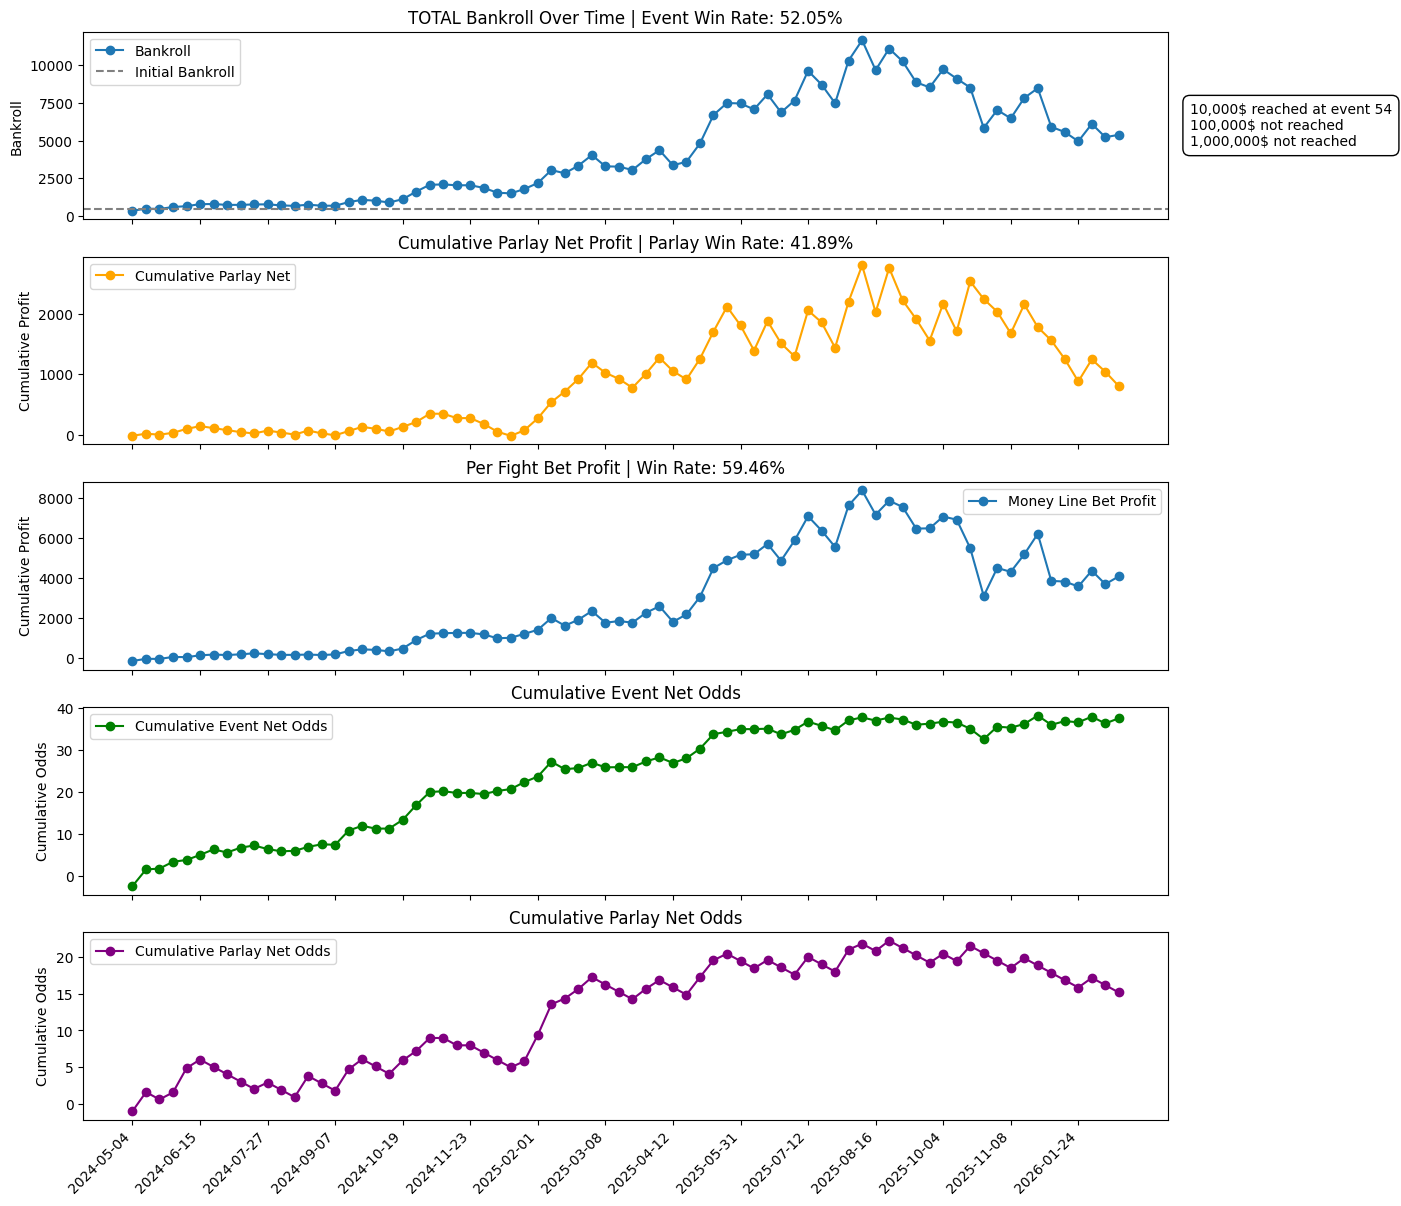

In [23]:
df_test_close = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close2.csv')


prob_cols = ['proba_blue', 'proba_red']
# fair_decimal_odds = ['dec_fair_open_blue', 'dec_fair_open_red']
fair_decimal_odds = ['dec_fair_close2_blue', 'dec_fair_close2_red']  # your decimal odds columns
real_decimal_odds = ['dec_close2_blue', 'dec_close2_red']
df_kelly2, df_kelly2_parlay = simulate_kelly(
    df_test_close,
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col='pred_winner',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    portfolio_scaling=False,
    adaptive_scaling=True,
    max_drawdown=.25,
    N=250,
    calc_parlay=True
)

plot_fp = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\close2_kelly_sim.png'
plot_backtest(df_kelly2, 500, path=plot_fp)

df_kelly2.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_close2.csv')
df_kelly2.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\streamlit\data\kelly_close2.csv')
df_kelly2_parlay.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\streamlit\data\parlay_close2.csv')

In [10]:
df_kelly = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_open.csv')
df_parlay = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\streamlit\data\parlay_open.csv')


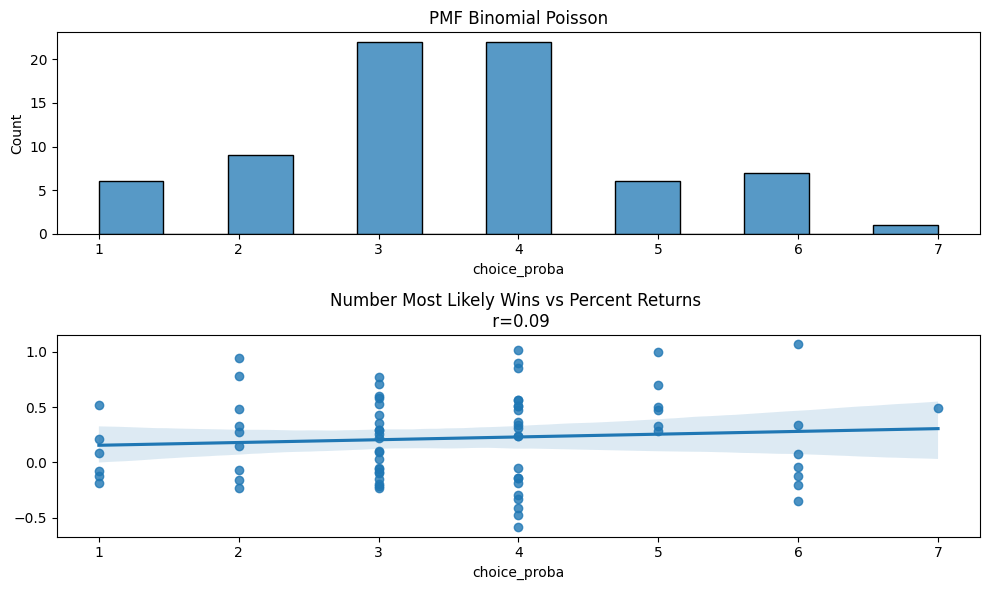

In [4]:
pmf_plot(df_kelly)

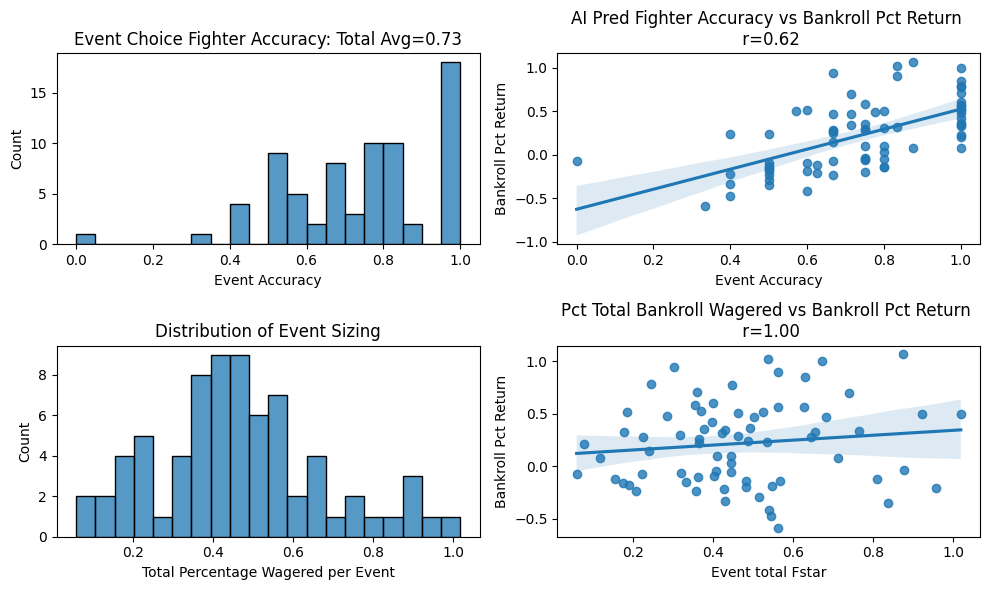

In [4]:
summary_stats(df_kelly)

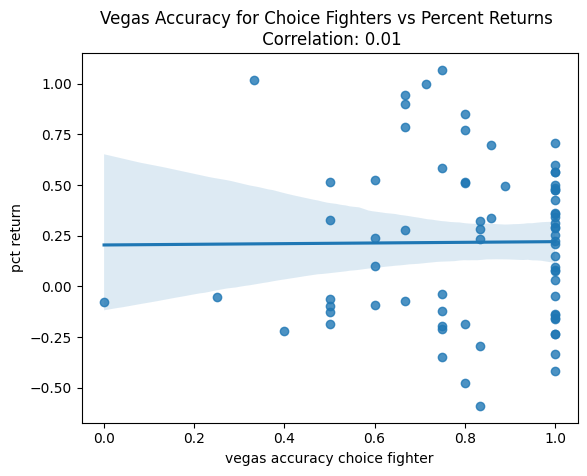

In [5]:
correlate_with_vegas(df_kelly)

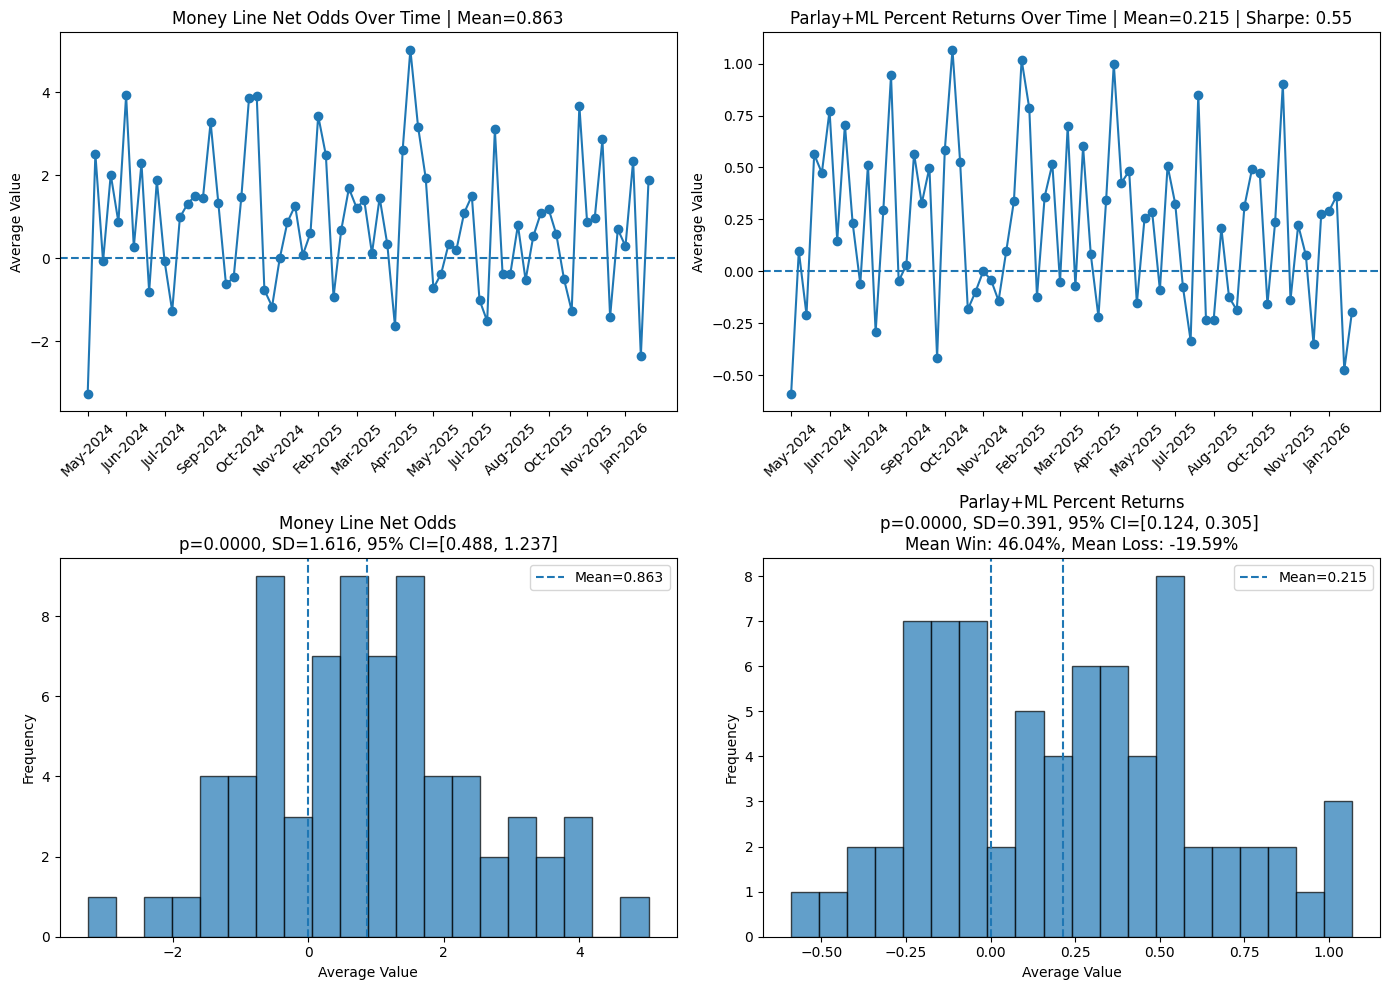

In [7]:
path = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\returns_distributions_open.png'
plot_event_odds_stats(df_kelly, path)

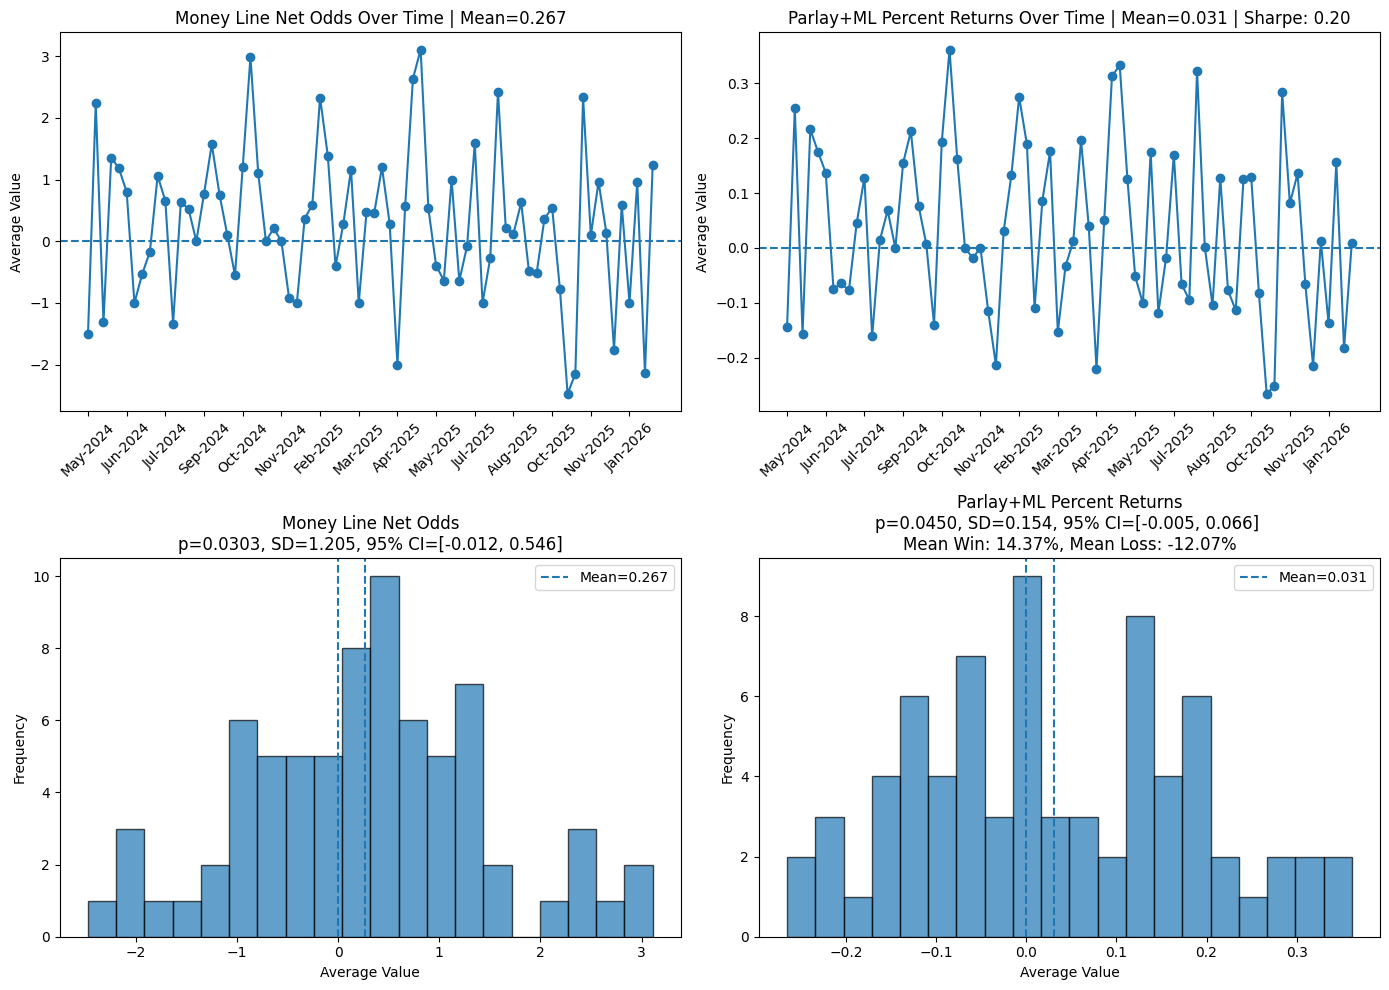

In [8]:
path = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\returns_distributions_close1.png'
plot_event_odds_stats(df_kelly1, path)

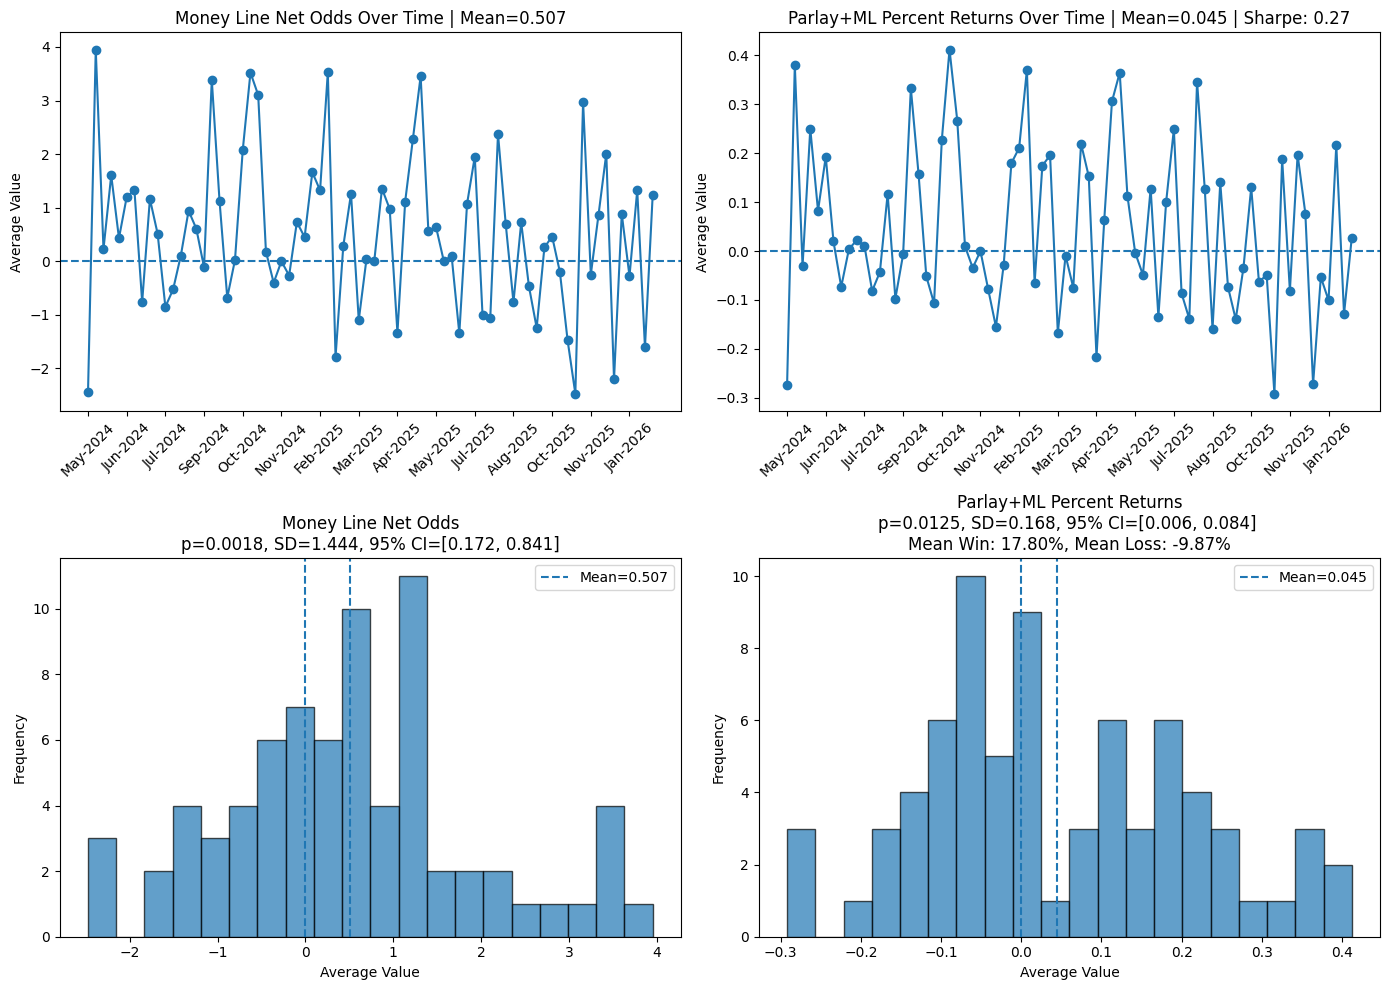

In [9]:
path = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\returns_distributions_close2.png'
plot_event_odds_stats(df_kelly2, path)

In [8]:
pct_positive = (
    df_kelly.groupby('date')['parlay_net_odds']
      .first()
      .gt(0)
      .mean()
)

pct_positive

np.float64(0.5)

https://wayback.archive-it.org/5456/20240920160238/https://www.eecs.harvard.edu/cs286r/courses/fall12/papers/Thorpe_KellyCriterion2007.pdf

https://medium.com/raposa-technologies/how-to-use-python-and-the-kelly-criterion-to-optimize-your-stock-portfolio-bb6e43df50c2



In [ ]:
https://web3.arxiv.org/abs/2207.14124?utm_source=chatgpt.com

https://pubmed.ncbi.nlm.nih.gov/35205582/

https://summit.sfu.ca/item/34958?utm_source=chatgpt.com


https://www.glicko.net/glicko/glicko2.pdf

https://www.glicko.net/glicko.html

https://ojs.aaai.org/index.php/AIIDE/article/view/5233


https://arxiv.org/abs/2303.16741?utm_source=chatgpt.com

https://opisthokonta.net/?cat=48


https://dashee87.github.io/football/python/predicting-football-results-with-statistical-modelling-dixon-coles-and-time-weighting/

